# Geospatial Data Retrieval Agent: Single-Agent Examples

This notebook shows how to call the GAS `geospatial_data_retrieval_agent` directly with the Python `gas-client` SDK.

It is intentionally self-contained:

- install `gas-client`
- configure credentials and a GAS server URL
- inspect the agent's `DescribeAgent` JSON
- run `ExecuteTask` in `stream`, `async`, and `sync` modes, in that order

The data requests below use public data sources that do not require source-specific API keys. The model-backed agent still needs an LLM credential accepted by the server. Check the agent's `DescribeAgent` JSON to confirm which credential names your deployment accepts.

## 1. Install The GAS Client SDK

Run this cell once in a fresh notebook environment.

In [24]:
%pip install gas-client

Note: you may need to restart the kernel to use updated packages.


## 2. Imports And Helper Functions

In [25]:
import json
import os
from pathlib import Path

from dotenv import load_dotenv
from gas_client import GasClient

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent


def pretty(data):
    print(json.dumps(data, indent=2, ensure_ascii=False))


## 3. Configure Server And Credentials

Use `default_credentials` for credentials that should be sent with every task request. You can override or add request-specific credentials in an individual `execute_task(...)` call.

The public GIBD deployment currently accepts `OPENAI_API_KEY` or `GIBD_API_KEY` for this model-backed agent. Other deployments may use different names, so check `DescribeAgent` before deciding which key to send.

In [26]:
load_dotenv(project_root / ".env")

server_url =  "http://127.0.0.1:4042"

default_credentials = {}
openai_api_key = os.getenv("OPENAI_API_KEY")
gibd_api_key = os.getenv("GIBD_API_KEY")

if openai_api_key:
    default_credentials["OPENAI_API_KEY"] = openai_api_key
if gibd_api_key:
    default_credentials["GIBD_API_KEY"] = gibd_api_key
if not default_credentials:
    raise RuntimeError("Set OPENAI_API_KEY or GIBD_API_KEY in the repo .env file before running this notebook.")

census_api_key = os.getenv("US_CENSUS_API_KEY")
if not census_api_key:
    raise RuntimeError("Set US_CENSUS_API_KEY in the repo .env file before running this notebook.")


client = GasClient(
    server_url,
    default_credentials=default_credentials,
    artifact_delivery="URL",
    timeout=900,
)

agent = client.agent("geospatial_data_retrieval_agent")
print("Server:", server_url)
print("Default credential names:", sorted(default_credentials))


Server: http://127.0.0.1:4042
Default credential names: ['OPENAI_API_KEY']


## 4. Inspect DescribeAgent

Use `DescribeAgent` to confirm supported modes, credentials, parameters, and source-specific credential requirements.

In [27]:
describe_agent = agent.describe()

profile = describe_agent.get("profile", {})
execute_task = describe_agent.get("execute_task", {})
print("Agent:", profile.get("name"))
print("Agent ID:", profile.get("agent_id"))
print("Supported modes:", execute_task.get("modes"))
print("Accepted model credential names:", execute_task.get("credentials", {}).get("one_of"))

# Uncomment to inspect the full profile.
# pretty(describe_agent)


Agent: Geospatial Data Retrieval Agent
Agent ID: geospatial_data_retrieval_agent
Supported modes: ['sync', 'async', 'stream']
Accepted model credential names: ['OPENAI_API_KEY', 'GIBD_API_KEY']


## 5. Stream Mode

`stream` mode keeps the connection open and yields progress events while the task runs. The final `task_result` event contains the standard GAS task response.

[17:56:14] stream_connected: Streaming connection established.
[17:56:15] Geospatial Data Retrieval Agent: I received your request.
[17:56:15] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[17:56:15] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[17:56:15] task_accepted: Task accepted. Starting streaming execution.
[17:56:15] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[17:56:15] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[17:56:17] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[17:56:17] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[17:56:17] Geospatial Data Retrieval Agent: I am comp

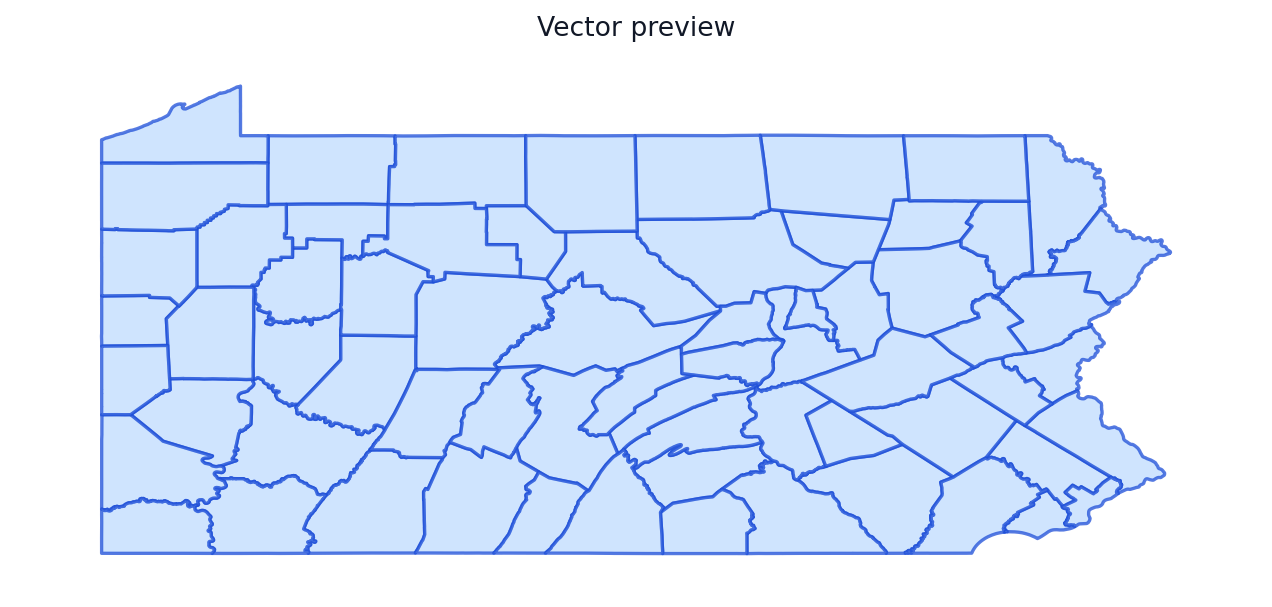

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363


In [28]:
stream_instructions = (
    "Download Pennsylvania county boundaries from the US Census Bureau. "
    "Return a geospatial vector dataset with county names and identifiers."
)

stream_result = agent.run_streaming_task(
    stream_instructions,
    artifact_delivery="URL",
    timeout=900,
)

client.print_artifacts(stream_result)
client.display_artifacts(stream_result)


## 6. Stream Mode: Census Demographic Data

This second streaming example retrieves Census demographic attributes. It demonstrates a data-source credential override through `credentials.source_credentials` while still using the client-level default LLM credential.

[17:56:25] stream_connected: Streaming connection established.
[17:56:25] Geospatial Data Retrieval Agent: I received your request.
[17:56:25] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[17:56:26] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[17:56:26] task_accepted: Task accepted. Starting streaming execution.
[17:56:26] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[17:56:26] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[17:56:27] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[17:56:27] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[17:56:27] Geospatial Data Retrieval Agent: I am comp

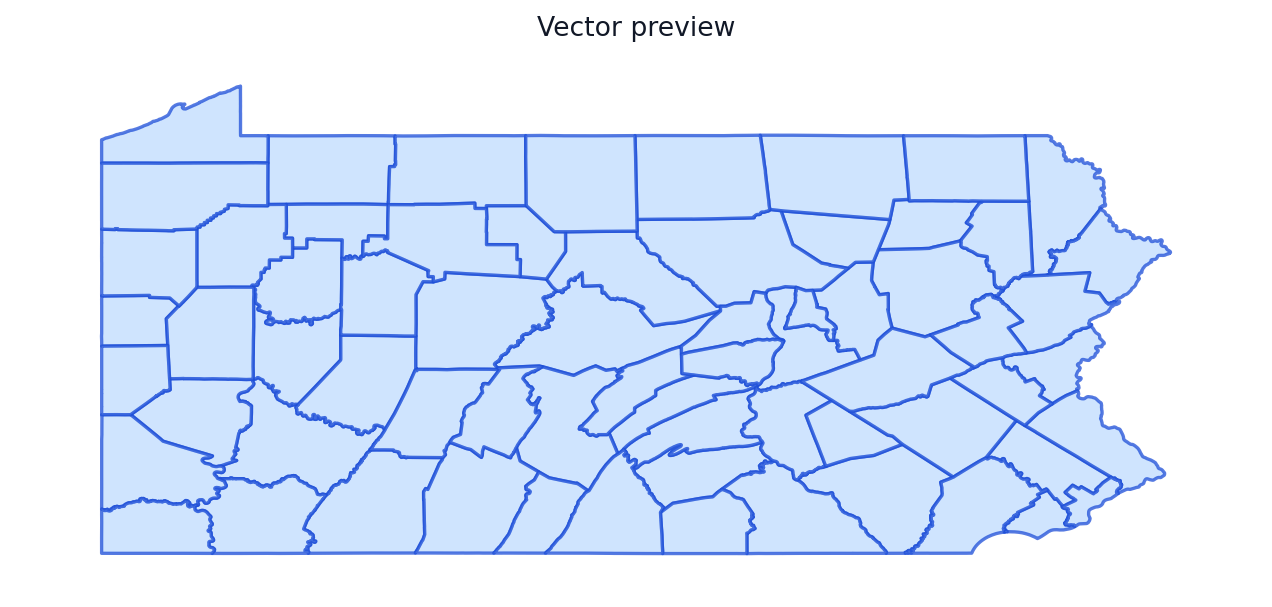

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [29]:
census_stream_instructions = (
    "Download 2021 county-level total population data for Pennsylvania from the US Census Bureau. "
)

census_credentials = {
    "source_credentials": {
        "US_Census_demography": {
            "key": census_api_key,
        }
    }
} 

census_stream_result = agent.run_streaming_task(
    census_stream_instructions,
    artifact_delivery="URL",
    credentials=census_credentials,
    timeout=900,
)

client.print_artifacts(census_stream_result)
client.display_artifacts(census_stream_result)


## 7. Async Mode

`async` mode returns quickly with a task ID. The client then polls until the task reaches a terminal status and retrieves the final result.

In [30]:
async_instructions = (
    "Download USGS earthquake events with magnitude 4.5 or greater from the past 30 days. "
    "Return the results as a geospatial point dataset."
)

async_submission = agent.execute_task(
    async_instructions,
    mode="async",
    artifact_delivery="URL",
    timeout=60,
)

pretty(async_submission)
async_task_id = client.get_task_id(async_submission)
print("Async task ID:", async_task_id)

{
  "response": {
    "type": "task_result",
    "schema_version": "1.0.0",
    "created_at": "2026-06-02T21:56:32.209576+00:00",
    "completed_at": null
  },
  "task": {
    "id": "2da6de0d-f7a1-4232-9e96-6396eca04b1d",
    "status": "accepted",
    "terminal": false,
    "user_request": "Download USGS earthquake events with magnitude 4.5 or greater from the past 30 days. Return the results as a geospatial point dataset.",
    "requested_skill": null,
    "artifact_delivery": "URL"
  },
  "agent": {
    "id": "geospatial_data_retrieval_agent",
    "name": null,
    "version": null,
    "model": null
  },
  "outputs": {
    "summary": "Task submitted.",
    "artifacts": [],
    "data_summary": {
      "type": null,
      "dimensions": null,
      "feature_count": null,
      "artifact_count": 0,
      "artifact_types": [],
      "formats": [],
      "crs": [],
      "combined_bbox": null,
      "has_vector": false,
      "has_raster": false,
      "has_table": false,
      "feature_co


GAS Task Summary
Task         : 2da6de0d-f7a1-4232-9e96-6396eca04b1d
Status       : successful
Agent        : Geospatial Data Retrieval Agent
Version      : 1.0.0
Model        : gpt-4o
Duration     : 11.39s
Iterations   : 4

Usage
-----
LLM calls    : 4
Tool calls   : 0
Input tokens : 4,906
Output tokens: 861
Total tokens : 5,767

Outputs
-------
Summary      : The geospatial data retrieval task has been completed successfully. The USGS earthquake events data with a magnitude of 4.5 or greater from the past 30 days was downloaded as a point dataset. We utilized the USGS_Earthquake source to gather 424 geospatial features, representing each earthquake event. The data is ready for analysis and visualization according to your requirements.
Artifacts    : 1
  1. Dataset (geospatial_data_retrieval_agent-9637-ihcu-2981.gpkg)
     type=downloadable_file format=gpkg size=163,840 bytes
     role=dataset_path
     original=download_usgs_483374.gpkg
     url=http://127.0.0.1:4042/agents/geospati

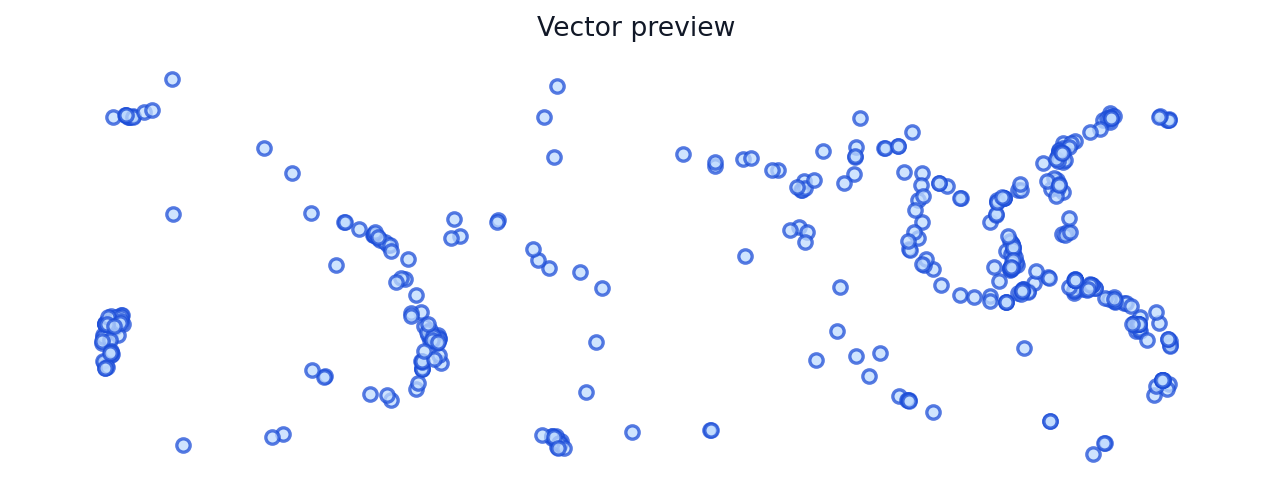

magnitude,place,time
5.4,"207 km WNW of Abepura, Indonesia",2026-06-01 23:01:17.102
6.2,"22 km WSW of Scarcelli, Italy",2026-06-01 22:12:36.284
4.6,"111 km SSW of Intipucá, El Salvador",2026-06-01 15:58:58.394
4.9,Macquarie Island region,2026-06-01 10:32:50.126
4.7,"189 km ESE of Alo, Wallis and Futuna",2026-06-01 06:26:16.415


In [31]:
async_result = agent.wait_for_task(
    async_task_id,
    poll_interval=5,
    timeout_seconds=900,
)

client.print_task_summary(async_result)
client.display_artifacts(async_result)

## 8. Sync Mode

`sync` mode waits for the final task result in the original request. It is simplest for short or moderate tasks.

In [32]:
sync_instructions = (
    "Download CDC PLACES county-level obesity prevalence data for Pennsylvania for 2020. "
    "Return a tabular or geospatial dataset with county identifiers and obesity measure values."
)

sync_result = agent.execute_task(
    sync_instructions,
    mode="sync",
    artifact_delivery="URL",
    timeout=900,
)

client.print_task_summary(sync_result)
client.display_artifacts(sync_result)



GAS Task Summary
Task         : 8419a7d2-a7cb-440e-baaa-93a1cb1a104c
Status       : successful
Agent        : Geospatial Data Retrieval Agent
Version      : 1.0.0
Model        : gpt-4o
Duration     : 11.20s
Iterations   : 4

Usage
-----
LLM calls    : 4
Tool calls   : 0
Input tokens : 3,069
Output tokens: 557
Total tokens : 3,626

Outputs
-------
Summary      : The 2020 CDC PLACES county-level obesity prevalence data for Pennsylvania has been successfully downloaded. This dataset includes both county identifiers and obesity measure values, providing insight into obesity prevalence across different counties within the state. The data was retrieved in a format conducive to tabular or geospatial analysis, ensuring it can be easily utilized for mapping and further research. This information will aid in understanding and addressing obesity trends at the county level in Pennsylvania.
Artifacts    : 1
  1. Dataset (geospatial_data_retrieval_agent-3779-jhzn-8415.csv)
     type=downloadable_fi

year,stateabbr,locationname,locationid,data_value,measureid
2020,PA,Juniata,42067,34.6,OBESITY
2020,PA,Potter,42105,36.4,OBESITY
2020,PA,Tioga,42117,34.5,OBESITY
2020,PA,Philadelphia,42101,30.2,OBESITY
2020,PA,Cambria,42021,33.2,OBESITY


In [33]:
results = {
    "stream": stream_result,
    "census_stream": census_stream_result,
    "async": async_result,
    "sync": sync_result,
}

for mode, result in results.items():
    status = result.get("task", {}).get("status")
    artifact_count = len(result.get("outputs", {}).get("artifacts", []))
    first_url = client.get_artifact_urls(result)[0]
    print(f"{mode:>6}: status={status}, artifacts={artifact_count}, first_artifact={first_url}")


stream: status=successful, artifacts=1, first_artifact=http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-0479-byvd-3904.gpkg
census_stream: status=successful, artifacts=1, first_artifact=http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-1206-tqhs-7875.gpkg
 async: status=successful, artifacts=1, first_artifact=http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-9637-ihcu-2981.gpkg
  sync: status=successful, artifacts=1, first_artifact=http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-3779-jhzn-8415.csv
